In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
data = pd.read_csv("translation_results.csv", encoding="utf-8")

In [25]:
data.head()

,run,category,source,target,input,status,result,response_time_ms,translation
0,1,basic translation,en,es,How are you?,200,PASS,2312,¿Cómo estás?
1,2,basic translation,en,es,How are you?,200,PASS,2672,¿Cómo estás?
2,3,basic translation,en,es,How are you?,200,PASS,1732,¿Cómo estás?
3,4,basic translation,en,es,How are you?,200,PASS,1713,¿Cómo estás?
4,5,basic translation,en,es,How are you?,200,PASS,2262,¿Cómo estás?


In [26]:
print(data.shape)
print(data["translation"].isna().sum())

(400, 9)
0


In [27]:
variation = (
    data.groupby(["source", "target", "input"])["translation"]
    .nunique()
    .sort_values(ascending=False)
)

variation.head()

source  target  input                                      
en      fr      Although it was late, we kept working.         2
es      en      La película empieza a las 7:30 de la tarde.    2
                María vive en Nueva York.                      2
en      fr      María lives in New York.                       2
fr      en      Le colis pèse 12,5 kilogrammes.                2
Name: translation, dtype: int64

In [33]:
variation_0 = (
    data[(data["source"] == "en") \
         & (data["target"] == "fr") \
            & (data["input"] == "Although it was late, we kept working.")] \
            [["run", "translation"]]
)

In [34]:
variation_0

,run,translation
290,1,"Bien qu'il fût tard, nous avons continué à tra..."
291,2,"Bien qu'il soit tard, nous avons continué à tr..."
292,3,"Bien qu'il soit tard, nous avons continué à tr..."
293,4,"Bien qu'il soit tard, nous avons continué à tr..."
294,5,"Bien qu'il soit tard, nous avons continué à tr..."
295,6,"Bien qu'il soit tard, nous avons continué à tr..."
296,7,"Bien qu'il soit tard, nous avons continué à tr..."
297,8,"Bien qu'il soit tard, nous avons continué à tr..."
298,9,"Bien qu'il soit tard, nous avons continué à tr..."
299,10,"Bien qu'il soit tard, nous avons continué à tr..."


In [36]:
variation_0["translation"].value_counts()

translation
Bien qu'il soit tard, nous avons continué à travailler.    9
Bien qu'il fût tard, nous avons continué à travailler.     1
Name: count, dtype: int64

In [43]:
variation_by_lang = data[["source", "target", "input", "translation"]].drop_duplicates()

In [48]:
variation_by_lang[variation_by_lang["target"] != "es"]

,source,target,input,translation
100,es,en,¿Cómo estás?,How are you?
110,es,en,¿Dónde está la estación de tren?,Where is the train station?
120,es,en,Está lloviendo a cántaros.,It's raining cats and dogs.
130,es,en,Deposité dinero en el banco.,I deposited money in the bank.
140,es,en,La película empieza a las 7:30 de la tarde.,The movie starts at 7:30 PM.
148,es,en,La película empieza a las 7:30 de la tarde.,The movie starts at 7:30 in the evening.
150,es,en,No creo que sea una buena idea.,I don't think it's a good idea.
160,es,en,María vive en Nueva York.,María lives in New York.
162,es,en,María vive en Nueva York.,Maria lives in New York.
170,es,en,¿Puedes ayudarme con este problema?,Can you help me with this problem?


In [77]:
variation_counts = (
    data.groupby(["source", "target", "input", "translation"])
    .size()
    .reset_index(name="count")
)

In [79]:
var_inputs = (
    data.groupby(["source", "target", "input"])["translation"]
    .nunique()
    .reset_index(name="unique_translations")
)

In [80]:
var_inputs = var_inputs[var_inputs["unique_translations"] > 1]

In [81]:
var_inputs

,source,target,input,unique_translations
10,en,fr,"Although it was late, we kept working.",2
11,en,fr,Can you help me with this problem?,2
16,en,fr,María lives in New York.,2
24,es,en,La película empieza a las 7:30 de la tarde.,2
25,es,en,María vive en Nueva York.,2
32,fr,en,J'ai déposé de l'argent à la banque.,2
33,fr,en,Je ne pense pas que ce soit une bonne idée.,2
34,fr,en,"Le colis pèse 12,5 kilogrammes.",2


In [82]:
variation_table = var_inputs.merge(
    variation_counts,
    on=["source", "target", "input"]
)

In [83]:
variation_table

,source,target,input,unique_translations,translation,count
0,en,fr,"Although it was late, we kept working.",2,"Bien qu'il fût tard, nous avons continué à tra...",1
1,en,fr,"Although it was late, we kept working.",2,"Bien qu'il soit tard, nous avons continué à tr...",9
2,en,fr,Can you help me with this problem?,2,Peux-tu m'aider avec ce problème ?,4
3,en,fr,Can you help me with this problem?,2,Pouvez-vous m'aider avec ce problème ?,6
4,en,fr,María lives in New York.,2,María habite à New York.,1
5,en,fr,María lives in New York.,2,María vit à New York.,9
6,es,en,La película empieza a las 7:30 de la tarde.,2,The movie starts at 7:30 PM.,9
7,es,en,La película empieza a las 7:30 de la tarde.,2,The movie starts at 7:30 in the evening.,1
8,es,en,María vive en Nueva York.,2,Maria lives in New York.,1
9,es,en,María vive en Nueva York.,2,María lives in New York.,9


In [87]:
variation_table[
    [
        "source",
        "target",
        "input",
        "translation",
        "count"
    ]
].sort_values(
    ["source", "target", "input", "count"],
    ascending=[True, True, True, False]
)

,source,target,input,translation,count
1,en,fr,"Although it was late, we kept working.","Bien qu'il soit tard, nous avons continué à tr...",9
0,en,fr,"Although it was late, we kept working.","Bien qu'il fût tard, nous avons continué à tra...",1
3,en,fr,Can you help me with this problem?,Pouvez-vous m'aider avec ce problème ?,6
2,en,fr,Can you help me with this problem?,Peux-tu m'aider avec ce problème ?,4
5,en,fr,María lives in New York.,María vit à New York.,9
4,en,fr,María lives in New York.,María habite à New York.,1
6,es,en,La película empieza a las 7:30 de la tarde.,The movie starts at 7:30 PM.,9
7,es,en,La película empieza a las 7:30 de la tarde.,The movie starts at 7:30 in the evening.,1
9,es,en,María vive en Nueva York.,María lives in New York.,9
8,es,en,María vive en Nueva York.,Maria lives in New York.,1


In [85]:
variation_table.groupby(
    ["source", "target", "input"]
)["count"].sum()

source  target  input                                      
en      fr      Although it was late, we kept working.         10
                Can you help me with this problem?             10
                María lives in New York.                       10
es      en      La película empieza a las 7:30 de la tarde.    10
                María vive en Nueva York.                      10
fr      en      J'ai déposé de l'argent à la banque.           10
                Je ne pense pas que ce soit une bonne idée.    10
                Le colis pèse 12,5 kilogrammes.                10
Name: count, dtype: int64

In [89]:
variation_by_pair = (
    var_inputs
    .groupby(["source", "target"])
    .size()
)

variation_by_pair

source  target
en      fr        3
es      en        2
fr      en        3
dtype: int64

In [103]:
var_inputs["language_pair"] = (
    var_inputs["source"].str.upper()
    + " → "
    + var_inputs["target"].str.upper()
)

In [91]:
variation_by_pair = (
    var_inputs["language_pair"]
    .value_counts()
    .reindex(
        ["EN → ES", "ES → EN", "EN → FR", "FR → EN"]
    )
)

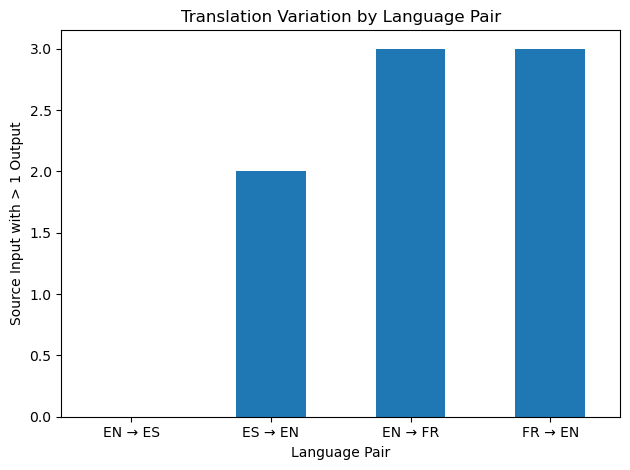

In [96]:
variation_by_pair.plot(kind="bar")

plt.title("Translation Variation by Language Pair")
plt.xlabel("Language Pair")
plt.ylabel("Source Input with > 1 Output")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(
    "translation_variation_by_language_pair.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [97]:
data.head()

,run,category,source,target,input,status,result,response_time_ms,translation
0,1,basic translation,en,es,How are you?,200,PASS,2312,¿Cómo estás?
1,2,basic translation,en,es,How are you?,200,PASS,2672,¿Cómo estás?
2,3,basic translation,en,es,How are you?,200,PASS,1732,¿Cómo estás?
3,4,basic translation,en,es,How are you?,200,PASS,1713,¿Cómo estás?
4,5,basic translation,en,es,How are you?,200,PASS,2262,¿Cómo estás?


In [98]:
data.describe()

,run,status,response_time_ms
count,400.000000,400.0,400.00000
mean,5.500000,200.0,1701.37750
std,2.875878,0.0,457.92075
min,1.000000,200.0,1259.00000
25%,3.000000,200.0,1470.75000
50%,5.500000,200.0,1572.00000
75%,8.000000,200.0,1747.75000
max,10.000000,200.0,4853.00000


In [106]:
latency_data = data.copy()

latency_data["language_pair"] = (
    latency_data["source"].str.upper()
    + " → "
    + latency_data["target"].str.upper()
)

In [107]:
latency_data.head()

,run,category,source,target,input,status,result,response_time_ms,translation,language_pair
0,1,basic translation,en,es,How are you?,200,PASS,2312,¿Cómo estás?,EN → ES
1,2,basic translation,en,es,How are you?,200,PASS,2672,¿Cómo estás?,EN → ES
2,3,basic translation,en,es,How are you?,200,PASS,1732,¿Cómo estás?,EN → ES
3,4,basic translation,en,es,How are you?,200,PASS,1713,¿Cómo estás?,EN → ES
4,5,basic translation,en,es,How are you?,200,PASS,2262,¿Cómo estás?,EN → ES


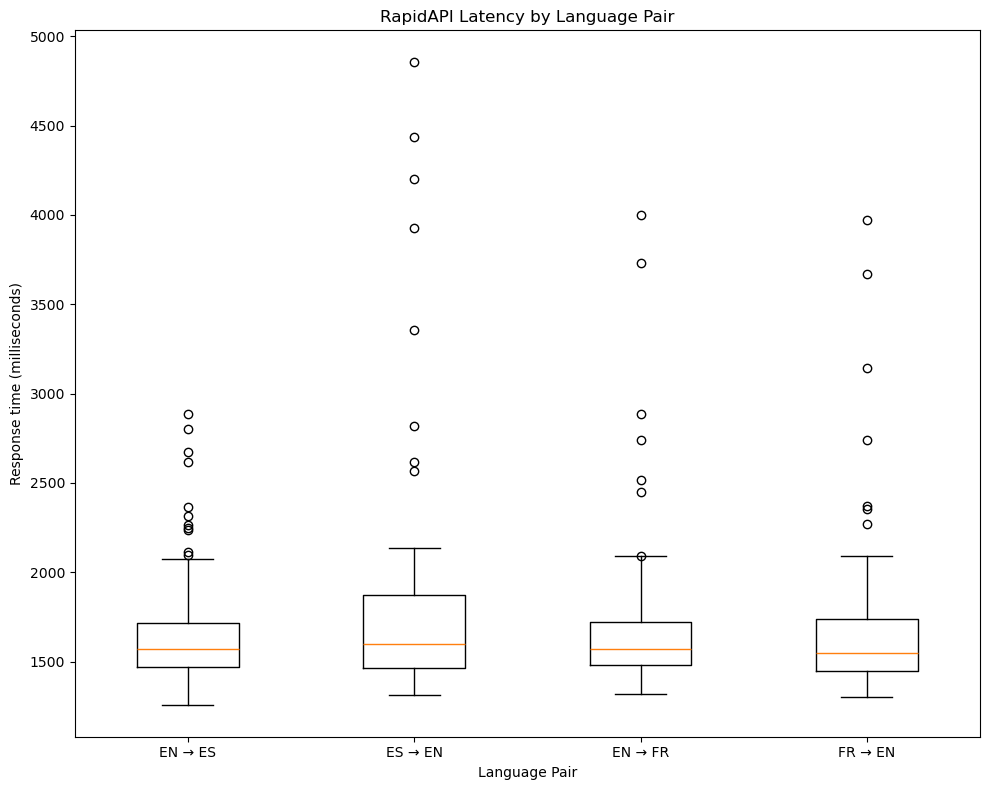

In [117]:
pairs = ["EN → ES", "ES → EN", "EN → FR", "FR → EN"]

latency_groups = [
    latency_data[latency_data["language_pair"] == pair]["response_time_ms"]
    for pair in pairs
]

fig = plt.figure(figsize=(10, 8))

plt.boxplot(
    latency_groups,
    labels=pairs
)

plt.title("RapidAPI Latency by Language Pair")
plt.xlabel("Language Pair")
plt.ylabel("Response time (milliseconds)")

plt.tight_layout()
plt.savefig("RapidAPI Latency by Language Pair")

plt.show()